<a href="https://colab.research.google.com/github/Komali-devireddy/UGV-Optimal-Path-Navigation-Using-A-/blob/main/UGV_Optimal_Path_Navigation_Using_A_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import heapq
import random
import time
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
GRID_SIZE = 70

# User-defined start and goal
START = (2, 2)
GOAL = (67, 67)

# Three obstacle density levels
DENSITIES = {
    "Low": 0.10,
    "Medium": 0.25,
    "High": 0.40
}

In [ ]:
START = (5, 5)
GOAL = (60, 60)

In [ ]:
def generate_grid(size, obstacle_density, start, goal):

    grid = np.zeros((size, size), dtype=int)

    for row in range(size):
        for col in range(size):

            if random.random() < obstacle_density:
                grid[row][col] = 1

    # Start and goal must always be free
    grid[start] = 0
    grid[goal] = 0

    return grid

In [ ]:
def astar(grid, start, goal):

    rows, cols = grid.shape

    # Priority queue:
    # (f_score, g_score, current_node)
    open_set = []

    heapq.heappush(
        open_set,
        (0, 0, start)
    )

    # Cost from start
    g_score = {
        start: 0
    }

    # Store previous node
    came_from = {}

    # Manhattan distance
    def heuristic(node):

        r, c = node
        gr, gc = goal

        return abs(r - gr) + abs(c - gc)

    # Four possible movements
    directions = [
        (-1, 0),
        (1, 0),
        (0, -1),
        (0, 1)
    ]

    expanded_nodes = 0

    while open_set:

        f_current, current_g, current = heapq.heappop(
            open_set
        )

        expanded_nodes += 1

        # Goal reached
        if current == goal:

            path = []

            while current in came_from:

                path.append(current)

                current = came_from[current]

            path.append(start)

            path.reverse()

            return path, expanded_nodes

        current_r, current_c = current

        # Explore neighbours
        for dr, dc in directions:

            nr = current_r + dr
            nc = current_c + dc

            neighbour = (nr, nc)

            # Check boundary
            if nr < 0 or nr >= rows:
                continue

            if nc < 0 or nc >= cols:
                continue

            # Check obstacle
            if grid[nr][nc] == 1:
                continue

            tentative_g = current_g + 1

            if (
                neighbour not in g_score
                or tentative_g < g_score[neighbour]
            ):

                came_from[neighbour] = current

                g_score[neighbour] = tentative_g

                f_score = (
                    tentative_g
                    + heuristic(neighbour)
                )

                heapq.heappush(
                    open_set,
                    (
                        f_score,
                        tentative_g,
                        neighbour
                    )
                )

    # No path found
    return None, expanded_nodes

In [ ]:
def display_grid(grid, path=None, start=None, goal=None, title="UGV Battlefield"):

    display = np.zeros(
        (grid.shape[0], grid.shape[1], 3)
    )

    # Free cells
    display[grid == 0] = [1, 1, 1]

    # Obstacles
    display[grid == 1] = [0, 0, 0]

    # Path
    if path is not None:

        for r, c in path:
            display[r, c] = [0, 0.8, 0]

    # Start
    if start is not None:
        display[start] = [0, 0, 1]

    # Goal
    if goal is not None:
        display[goal] = [1, 0, 0]

    plt.figure(figsize=(8, 8))

    plt.imshow(display)

    plt.title(title)

    plt.xlabel("X coordinate")
    plt.ylabel("Y coordinate")

    plt.show()

In [ ]:
grid = generate_grid(
    GRID_SIZE,
    DENSITIES["Low"],
    START,
    GOAL
)

path, expanded = astar(
    grid,
    START,
    GOAL
)

if path is not None:

    print("Path found!")
    print("Path length:", len(path) - 1)
    print("Nodes expanded:", expanded)

else:

    print("No path exists.")

Path found!
Path length: 110
Nodes expanded: 2407


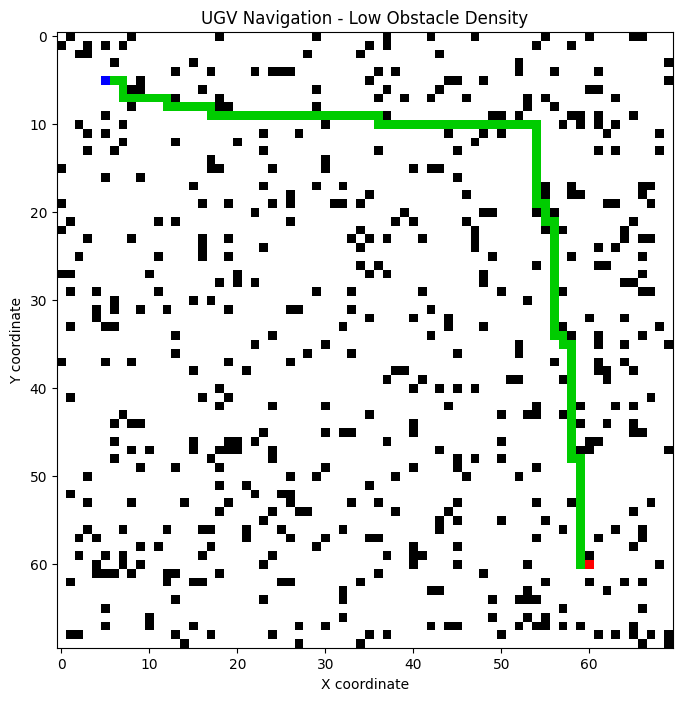

In [ ]:
if path is not None:

    display_grid(
        grid,
        path,
        START,
        GOAL,
        "UGV Navigation - Low Obstacle Density"
    )

In [ ]:
results = []

for density_name, density in DENSITIES.items():

    print("\nRunning:", density_name)

    grid = generate_grid(
        GRID_SIZE,
        density,
        START,
        GOAL
    )

    start_time = time.perf_counter()

    path, expanded = astar(
        grid,
        START,
        GOAL
    )

    execution_time = (
        time.perf_counter()
        - start_time
    )

    if path is not None:

        path_length = len(path) - 1

        direct_distance = (
            abs(START[0] - GOAL[0])
            + abs(START[1] - GOAL[1])
        )

        efficiency = (
            direct_distance
            / path_length
        ) * 100

        success = 1

    else:

        path_length = np.nan
        efficiency = 0
        success = 0

    results.append({
        "Density": density_name,
        "Obstacle %": density * 100,
        "Path Length": path_length,
        "Nodes Expanded": expanded,
        "Execution Time (sec)": execution_time,
        "Path Efficiency (%)": efficiency,
        "Success": success
    })


Running: Low

Running: Medium

Running: High


In [ ]:
import pandas as pd

In [ ]:
results_df = pd.DataFrame(results)

display(results_df)

,Density,Obstacle %,Path Length,Nodes Expanded,Execution Time (sec),Path Efficiency (%),Success
0,Low,10.0,110.0,2204,0.013167,100.000000,1
1,Medium,25.0,112.0,1136,0.004769,98.214286,1
2,High,40.0,NaN,1452,0.005040,0.000000,0


In [ ]:
TRIALS = 20

all_results = []

for density_name, density in DENSITIES.items():

    for trial in range(TRIALS):

        grid = generate_grid(
            GRID_SIZE,
            density,
            START,
            GOAL
        )

        start_time = time.perf_counter()

        path, expanded = astar(
            grid,
            START,
            GOAL
        )

        execution_time = (
            time.perf_counter()
            - start_time
        )

        if path is not None:

            path_length = len(path) - 1

            direct_distance = (
                abs(START[0] - GOAL[0])
                + abs(START[1] - GOAL[1])
            )

            efficiency = (
                direct_distance
                / path_length
            ) * 100

            success = 1

        else:

            path_length = np.nan
            efficiency = 0
            success = 0

        all_results.append({
            "Density": density_name,
            "Trial": trial + 1,
            "Path Length": path_length,
            "Nodes Expanded": expanded,
            "Execution Time": execution_time,
            "Efficiency": efficiency,
            "Success": success
        })

all_results_df = pd.DataFrame(all_results)

display(all_results_df)

,Density,Trial,Path Length,Nodes Expanded,Execution Time,Efficiency,Success
0,Low,1,110.0,2381,0.010552,100.000000,1
1,Low,2,110.0,2211,0.008520,100.000000,1
2,Low,3,110.0,2611,0.018486,100.000000,1
3,Low,4,110.0,2493,0.018267,100.000000,1
4,Low,5,110.0,2452,0.016252,100.000000,1
5,Low,6,110.0,2540,0.011988,100.000000,1
6,Low,7,110.0,2646,0.009748,100.000000,1
7,Low,8,110.0,2363,0.008504,100.000000,1
8,Low,9,110.0,2410,0.008992,100.000000,1
9,Low,10,110.0,2546,0.009321,100.000000,1


In [ ]:
summary = all_results_df.groupby(
    "Density"
).agg({
    "Path Length": "mean",
    "Nodes Expanded": "mean",
    "Execution Time": "mean",
    "Efficiency": "mean",
    "Success": "mean"
}).reset_index()

summary["Success Rate (%)"] = (
    summary["Success"] * 100
)

summary = summary.drop(
    columns=["Success"]
)

display(summary)

,Density,Path Length,Nodes Expanded,Execution Time,Efficiency,Success Rate (%)
0,High,134.666667,580.65,0.001857,12.309966,15.0
1,Low,110.100000,2453.05,0.010586,99.910714,100.0
2,Medium,110.947368,1240.10,0.004518,94.202694,95.0


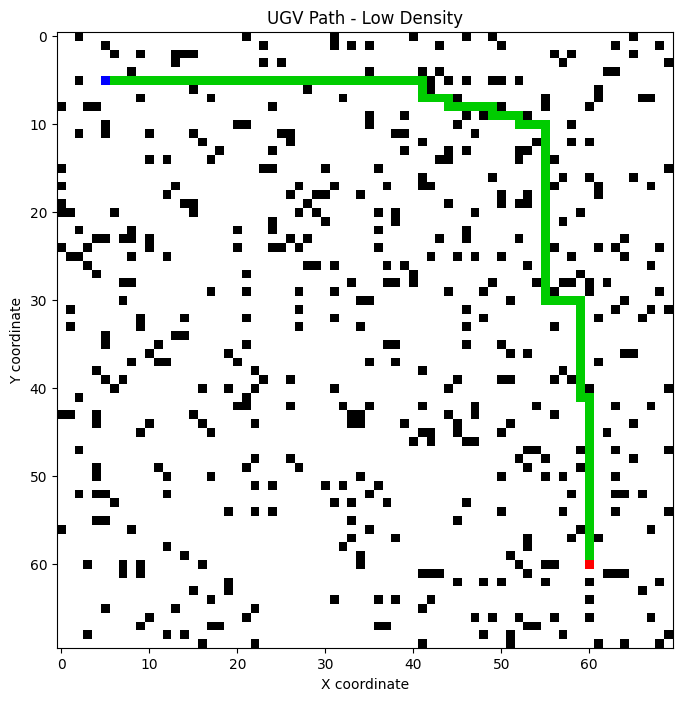

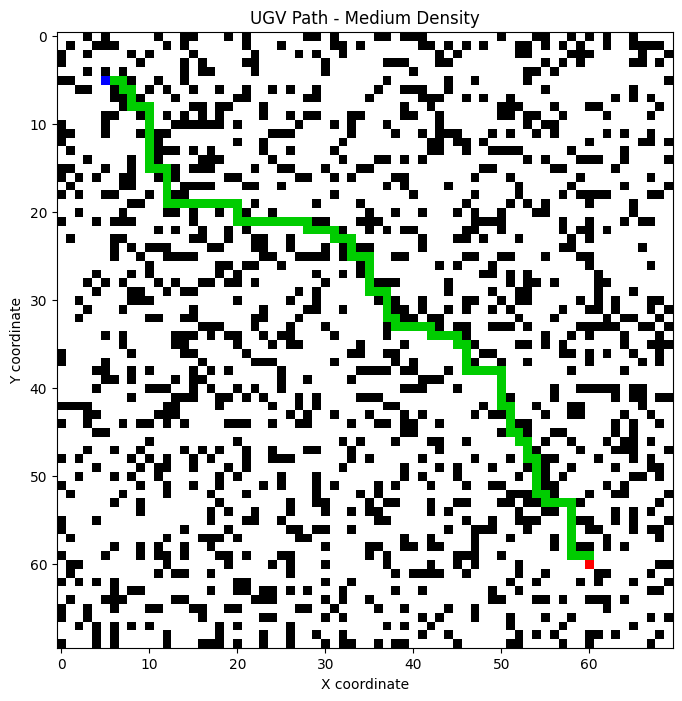

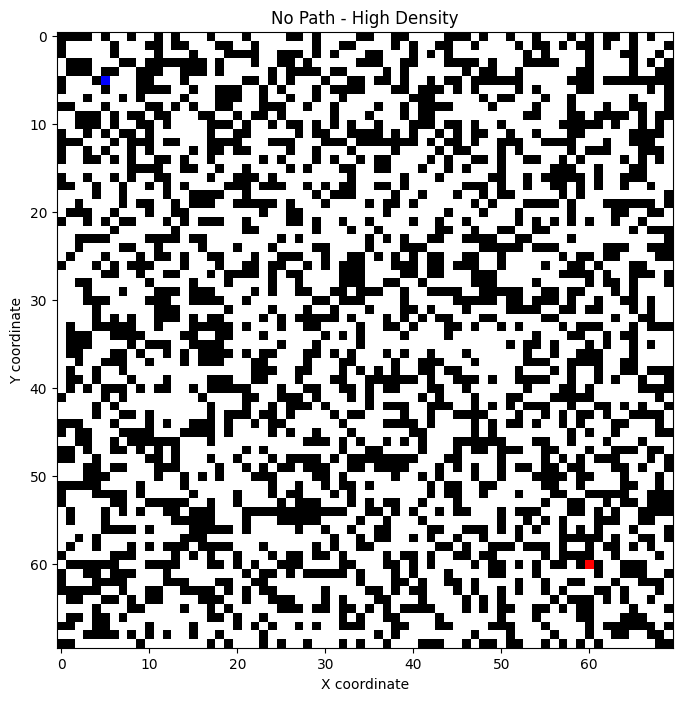

In [ ]:
for density_name, density in DENSITIES.items():

    grid = generate_grid(
        GRID_SIZE,
        density,
        START,
        GOAL
    )

    path, expanded = astar(
        grid,
        START,
        GOAL
    )

    if path is not None:

        display_grid(
            grid,
            path,
            START,
            GOAL,
            f"UGV Path - {density_name} Density"
        )

    else:

        display_grid(
            grid,
            None,
            START,
            GOAL,
            f"No Path - {density_name} Density"
        )